In [1]:
import sys
import os
import importlib

parent = os.path.dirname(os.getcwd())
sys.path.insert(0, parent)

from Helpers import loadData, multiplot, sphereMask, saveData, chunker, unchunker, kernelPad
importlib.reload(sys.modules['Helpers'])
importlib.reload(sys.modules['Helpers.saveData'])
importlib.reload(sys.modules['Helpers'])
print(parent)

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.fft as fft
import torch.nn.functional as F
from scipy.ndimage import convolve
import stackview
from scipy.ndimage import zoom

from sklearn.preprocessing import normalize
from skimage.feature import peak_local_max
from scipy.signal import fftconvolve
from skimage.feature import peak_local_max as pk

d:\temp1\Granular-Compression\Identification


In [17]:
# Load downscaled data
name = 'pCycle4s3'
path = os.path.join(os.path.dirname(parent),'Data')
data = loadData(location=path, fileName=name+'.hdf5')

In [18]:
# Determine current device
device = torch.cuda.get_device_name()

if device == 'NVIDIA RTX A2000 12GB':
    client = 'Desktop'; cuts = 2
if device == 'NVIDIA RTX 4000 Ada Generation':
    client = 'Server';  cuts = 1

print(f'Identified {client}: {device}')

Identified Desktop: NVIDIA RTX A2000 12GB


In [22]:
# Display data dims
r,c,z = data.shape
print(f'Data dims: {r,c,z}')

# Crop to proper data dims
cropData = data[:,:936,:944]; r,c,z = cropData.shape
print(f'Data dims: {r,c,z}')

# Check size validity for server
if client == 'Server':
    if r % 2 == 1 and c % 2 == 1 and z % 4 == 0:
        print('Valid size')
    else:
        print('Requirements failed')
        raise TypeError

# Check size validity for desktop
elif client == 'Desktop':
    if r % 2 == 1 and c % 4 == 0 and z % 4 == 0:
        print('Valid size')
    else:
        print('Requirements failed')
        raise TypeError

Data dims: (901, 938, 947)
Data dims: (901, 936, 944)
Valid size


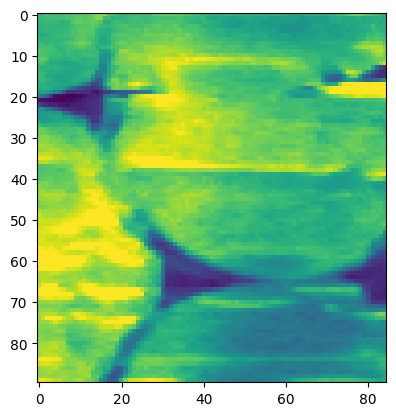

In [23]:
# Find a particle to base your kernel off of, adjust the cut manually
particle = cropData[445:535,80:165,195]
plt.imshow(particle);

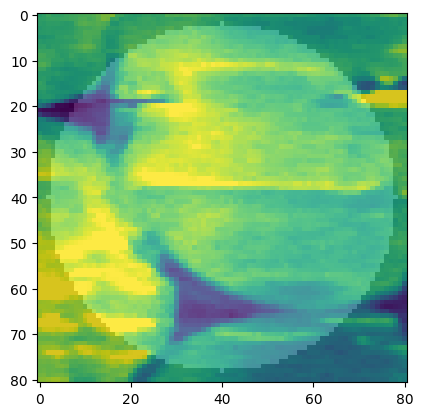

In [24]:
# Create sphere conv mask
kernel = sphereMask(diameter=126,pad=2,scale=.6)
kP = kernel.shape[0]//2+1

# Check for center point
assert kernel.shape[0] % 2 == 1, f'Kernel must be odd: {kernel.shape}'
assert kP % 2 == 1 ,             f'Kernel padding must be odd: kP={kP}'

# Visualize against particle
plt.imshow(particle)
plt.imshow(kernel[:,:,kernel.shape[2]//2], alpha=.15,cmap='grey');

In [25]:
# Break data into chunks, padding each

# Split data
upper = cropData[:,:,   int(z/2)-kP: ] # U
lower = cropData[:,:, 0:int(z/2)+kP  ] # L

# Keep 2 split if server
if client == 'Server':
    kChunks = [lower,upper]

# Split into 4 if desktop
if client == 'Desktop':
    ul,uu = upper[:, :int(c/2)+kP ,:], upper[:, int(c/2)-kP: ,:]
    ll,lu = lower[:, :int(c/2)+kP ,:], lower[:, int(c/2)-kP: ,:]
    kChunks = [ll,ul,lu,uu]

# Pad chunks
pChunks = [np.pad(chunk,pad_width=kP) for chunk in kChunks]

In [26]:
# Pad kernel to data chunk dimensions
expansionPadding = [(chunkDim-kernelDim)//2 for chunkDim, kernelDim in zip(pChunks[0].shape, kernel.shape)]
pKernel          = np.pad(kernel, pad_width=((expansionPadding[0],expansionPadding[0]),
                                             (expansionPadding[1],expansionPadding[1]),
                                             (expansionPadding[2],expansionPadding[2])))

In [27]:
# Confirm sizes are equal
print(f'Padded chunk size:  {pChunks[0].shape}')
print(f'Padded kernel size: {pKernel.shape}')

Padded chunk size:  (983, 591, 595)
Padded kernel size: (983, 591, 595)


In [28]:
# FFT kernel
gKern = torch.from_numpy(pKernel).cuda()
fgKern = fft.rfftn(fft.ifftshift(gKern))
del gKern

# Create convolutions of kernel and data chunks
convMaps = []; chunkSz = pChunks[0].shape;
for chunk in pChunks:

    # FFT data chunk
    gChunk = torch.from_numpy(chunk).cuda()
    fgChunk = fft.rfftn(gChunk)
    del gChunk

    # Convolve and IFFT
    fgChunk *= fgKern
    gChunk = fft.irfftn(fgChunk, s=chunkSz)
    del fgChunk

    # Gain back memory
    fChunk = gChunk.cpu()
    del gChunk

    # Add convolved chunk to list
    convMaps.append(fChunk)

In [29]:
def conjoin(inp):
    """Conjoin all chunks together into one matrix, and return result"""
    
    ll,ul,lu,uu = inp
    ll_unpad = ll[kP:-kP, kP:-kP, kP:-kP]  # Now shape (r, 266, z_chunk)
    ul_unpad = ul[kP:-kP, kP:-kP, kP:-kP]
    lu_unpad = lu[kP:-kP, kP:-kP, kP:-kP]  
    uu_unpad = uu[kP:-kP, kP:-kP, kP:-kP]

    # Combine column chunks
    columnComb1 = np.concatenate(
        (ll_unpad[:, :c//2, :],      # First 256 columns from ll
         lu_unpad[:, -c//2:, :]),    # Last 256 columns from lu
        axis=1
    )
    columnComb2 = np.concatenate(
        (ul_unpad[:, :c//2, :],      
         uu_unpad[:, -c//2:, :]),    
        axis=1
    )
        
    # Combine z chunks
    zedComb = np.concatenate(
        (columnComb1[:, :, :z//2],   
         columnComb2[:, :, -z//2:]), 
        axis=2
    )
    
    # Return unpadded, total array
    return zedComb[kP:-kP,kP:-kP,kP:-kP]

In [30]:
# Reconjoin data
conData = conjoin(convMaps)
reData  = conjoin(pChunks)

# Assure equivelence
print(f'Unconvolved data: {cropData.shape}')
print(f'Convolved data: {conData.shape}')
print(f'Padded data:    {reData.shape}')

# Normalize conv data for later
normConv = (conData - np.min(conData))/(np.max(conData) - np.min(conData))

Unconvolved data: (901, 936, 944)
Convolved data: (819, 854, 862)
Padded data:    (819, 854, 862)


In [31]:
# Save convolution and its matching data
saveData(normConv, path, 'f'+name[1:]+'Conv.hdf5')
saveData(reData, path, 'f'+name[1:]+'Raw.hdf5')